# A document scanner that reads handwritten digits

The photos in this notebook show sheets of A4 paper on the floor, with handwritten digits of different sizes, taken from many angles. The goal is to build, from classic computer vision plus one small neural network, a pipeline that:

1. **finds the sheet** in the photo;
2. detects its four borders with the **Hough transform** and computes the corners;
3. **rectifies** the sheet with a homography, as a document-scanner app does;
4. **segments** the handwritten digits and **reads** them with a CNN trained on MNIST.

The geometric steps live in `scanner.py`; everything else is in the notebook. The pipeline is run on all 31 photos, and the cases where it fails are analysed.

In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage as ndi
from skimage import filters, io, measure, morphology, transform
from torchvision import datasets, transforms

from scanner import border_lines, find_corners, load_gray, rectify, sheet_mask

torch.manual_seed(0)
torch.set_num_threads(16)
plt.rcParams["figure.dpi"] = 100

photos = sorted(glob.glob("data/sheets/*.jpg"), key=lambda p: int(p.split("_")[-1].split(".")[0]))
print(f"{len(photos)} photos, each {io.imread(photos[0]).shape[1]} x {io.imread(photos[0]).shape[0]} pixels")

31 photos, each 4032 x 3024 pixels


## 1. Step by step on one photo

### Finding the sheet

The sheet is the largest bright region. We smooth the image, threshold it with Otsu's method, close small gaps and fill the holes left by the handwriting, and keep the largest connected component. Images are downscaled by 4 first: the geometry does not need 12 megapixels.

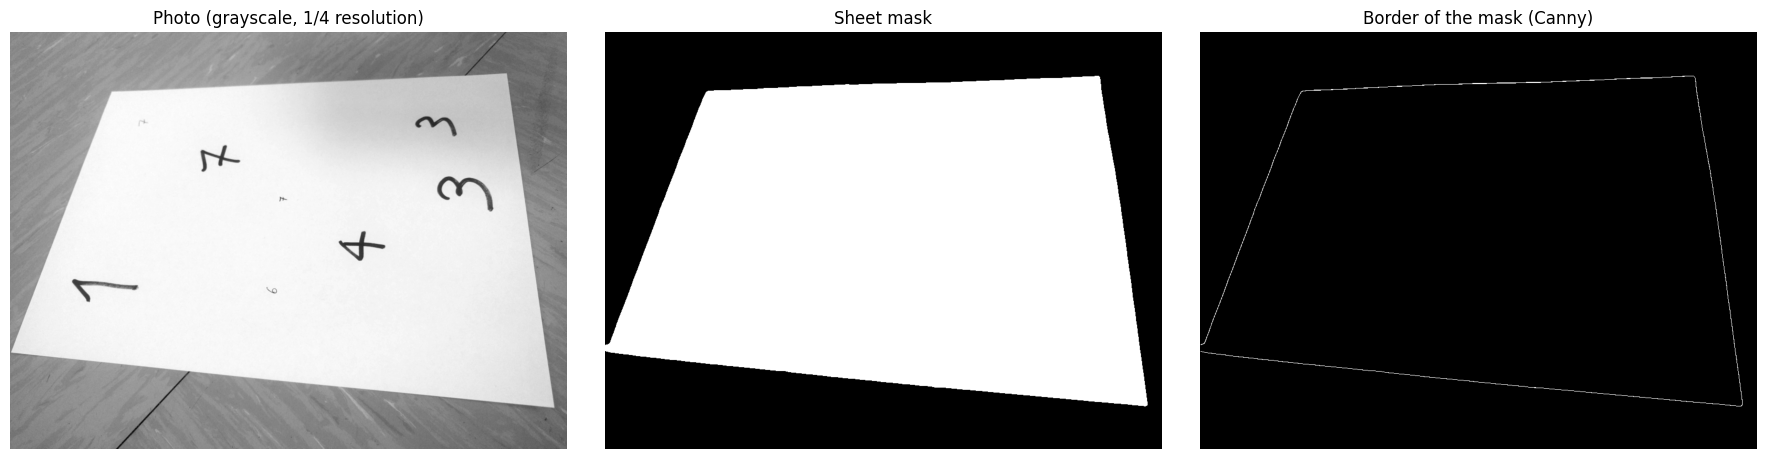

In [2]:
gray = load_gray(photos[0])
mask = sheet_mask(gray)
edges, h, theta, dist, lines = border_lines(mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Photo (grayscale, 1/4 resolution)")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Sheet mask")
axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Border of the mask (Canny)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

### Detecting the borders: the Hough transform

A straight line can be written as $x\cos\theta + y\sin\theta = d$. The **Hough transform** lets every edge pixel vote for all the $(\theta, d)$ pairs of lines passing through it. Pixels on the same line vote for the same pair, so lines appear as bright peaks in the accumulator.

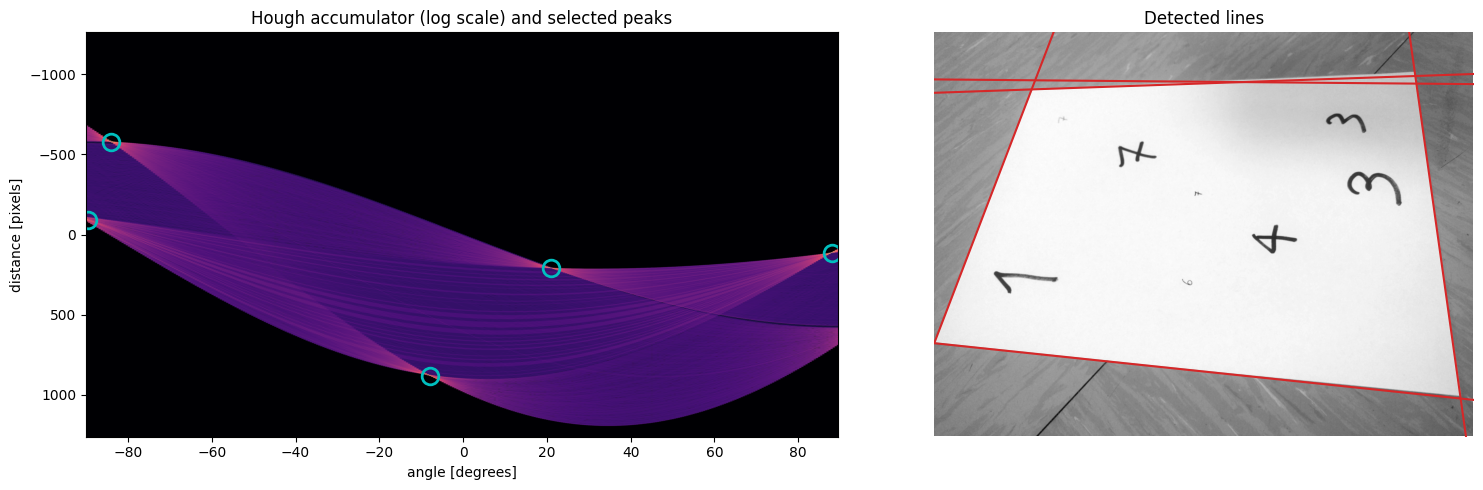

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.imshow(np.log1p(h), extent=[np.degrees(theta[0]), np.degrees(theta[-1]), dist[-1], dist[0]], aspect="auto", cmap="magma")
for a, d in lines:
    ax1.plot(np.degrees(a), d, "co", fillstyle="none", ms=12, mew=2)
ax1.set(xlabel="angle [degrees]", ylabel="distance [pixels]", title="Hough accumulator (log scale) and selected peaks")

ax2.imshow(gray, cmap="gray")
for a, d in lines:
    ax2.axline((d * np.cos(a), d * np.sin(a)), slope=np.tan(a + np.pi / 2), color="tab:red", lw=1.5)
ax2.set(xlim=(0, gray.shape[1]), ylim=(gray.shape[0], 0), title="Detected lines")
ax2.axis("off")
fig.tight_layout()
plt.show()

### From lines to corners

The detector may return more than four lines, for example from the shadow along a border. `find_corners` tries every set of four lines, keeps only those that form two pairs of roughly parallel lines (opposite sides of the sheet; perspective allows up to 35 degrees between them), intersects each line of one pair with each line of the other, and scores the resulting quadrilateral by how well its area matches the sheet mask. A quadrilateral is accepted only if the overlap is at least 90%.

overlap with the mask: 1.00
                  x      y
top-left      181.8  106.7
top-right     899.1   81.7
bottom-right  983.9  684.6
bottom-left    -0.3  581.2


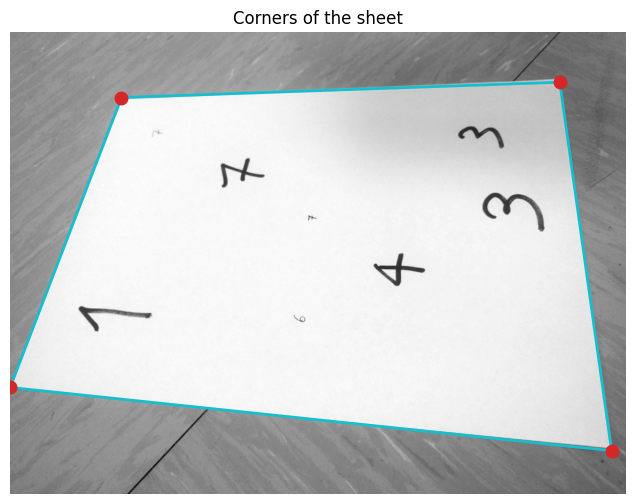

In [4]:
corners, score = find_corners(mask, lines)
print(f"overlap with the mask: {score:.2f}")
print(pd.DataFrame(corners, columns=["x", "y"], index=["top-left", "top-right", "bottom-right", "bottom-left"]).round(1))

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(gray, cmap="gray")
closed = np.vstack([corners, corners[:1]])
ax.plot(closed[:, 0], closed[:, 1], "-", color="tab:cyan", lw=2)
ax.plot(corners[:, 0], corners[:, 1], "o", color="tab:red", ms=9)
ax.set_title("Corners of the sheet")
ax.axis("off")
plt.show()

### Rectification with a homography

A **homography** is the projective transformation that maps the plane of the sheet to the image plane. Four point correspondences (the corners and the corners of an A4 rectangle) determine its 8 parameters, and warping the photo with its inverse gives the sheet as seen from straight above, with the A4 aspect ratio of $\sqrt{2}$.

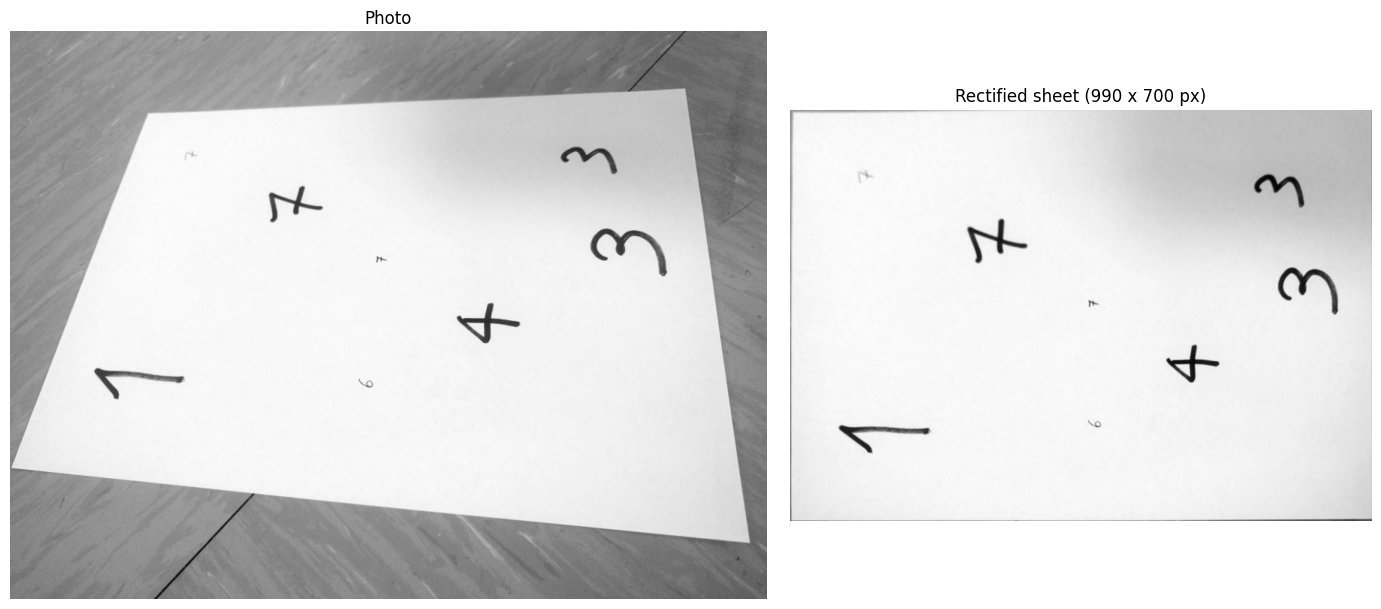

homography matrix (output -> input):
[[ 5.715000e-01 -2.604000e-01  1.818325e+02]
 [-3.930000e-02  4.654000e-01  1.067191e+02]
 [-2.000000e-04 -4.000000e-04  1.000000e+00]]


In [5]:
warped, tform = rectify(gray, corners)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.33, 1]})
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Photo")
axes[1].imshow(warped, cmap="gray")
axes[1].set_title(f"Rectified sheet ({warped.shape[1]} x {warped.shape[0]} px)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()
print("homography matrix (output -> input):")
print(np.round(tform.params, 4))

## 2. Running the scanner on all photos

rectified automatically: 13 of 31


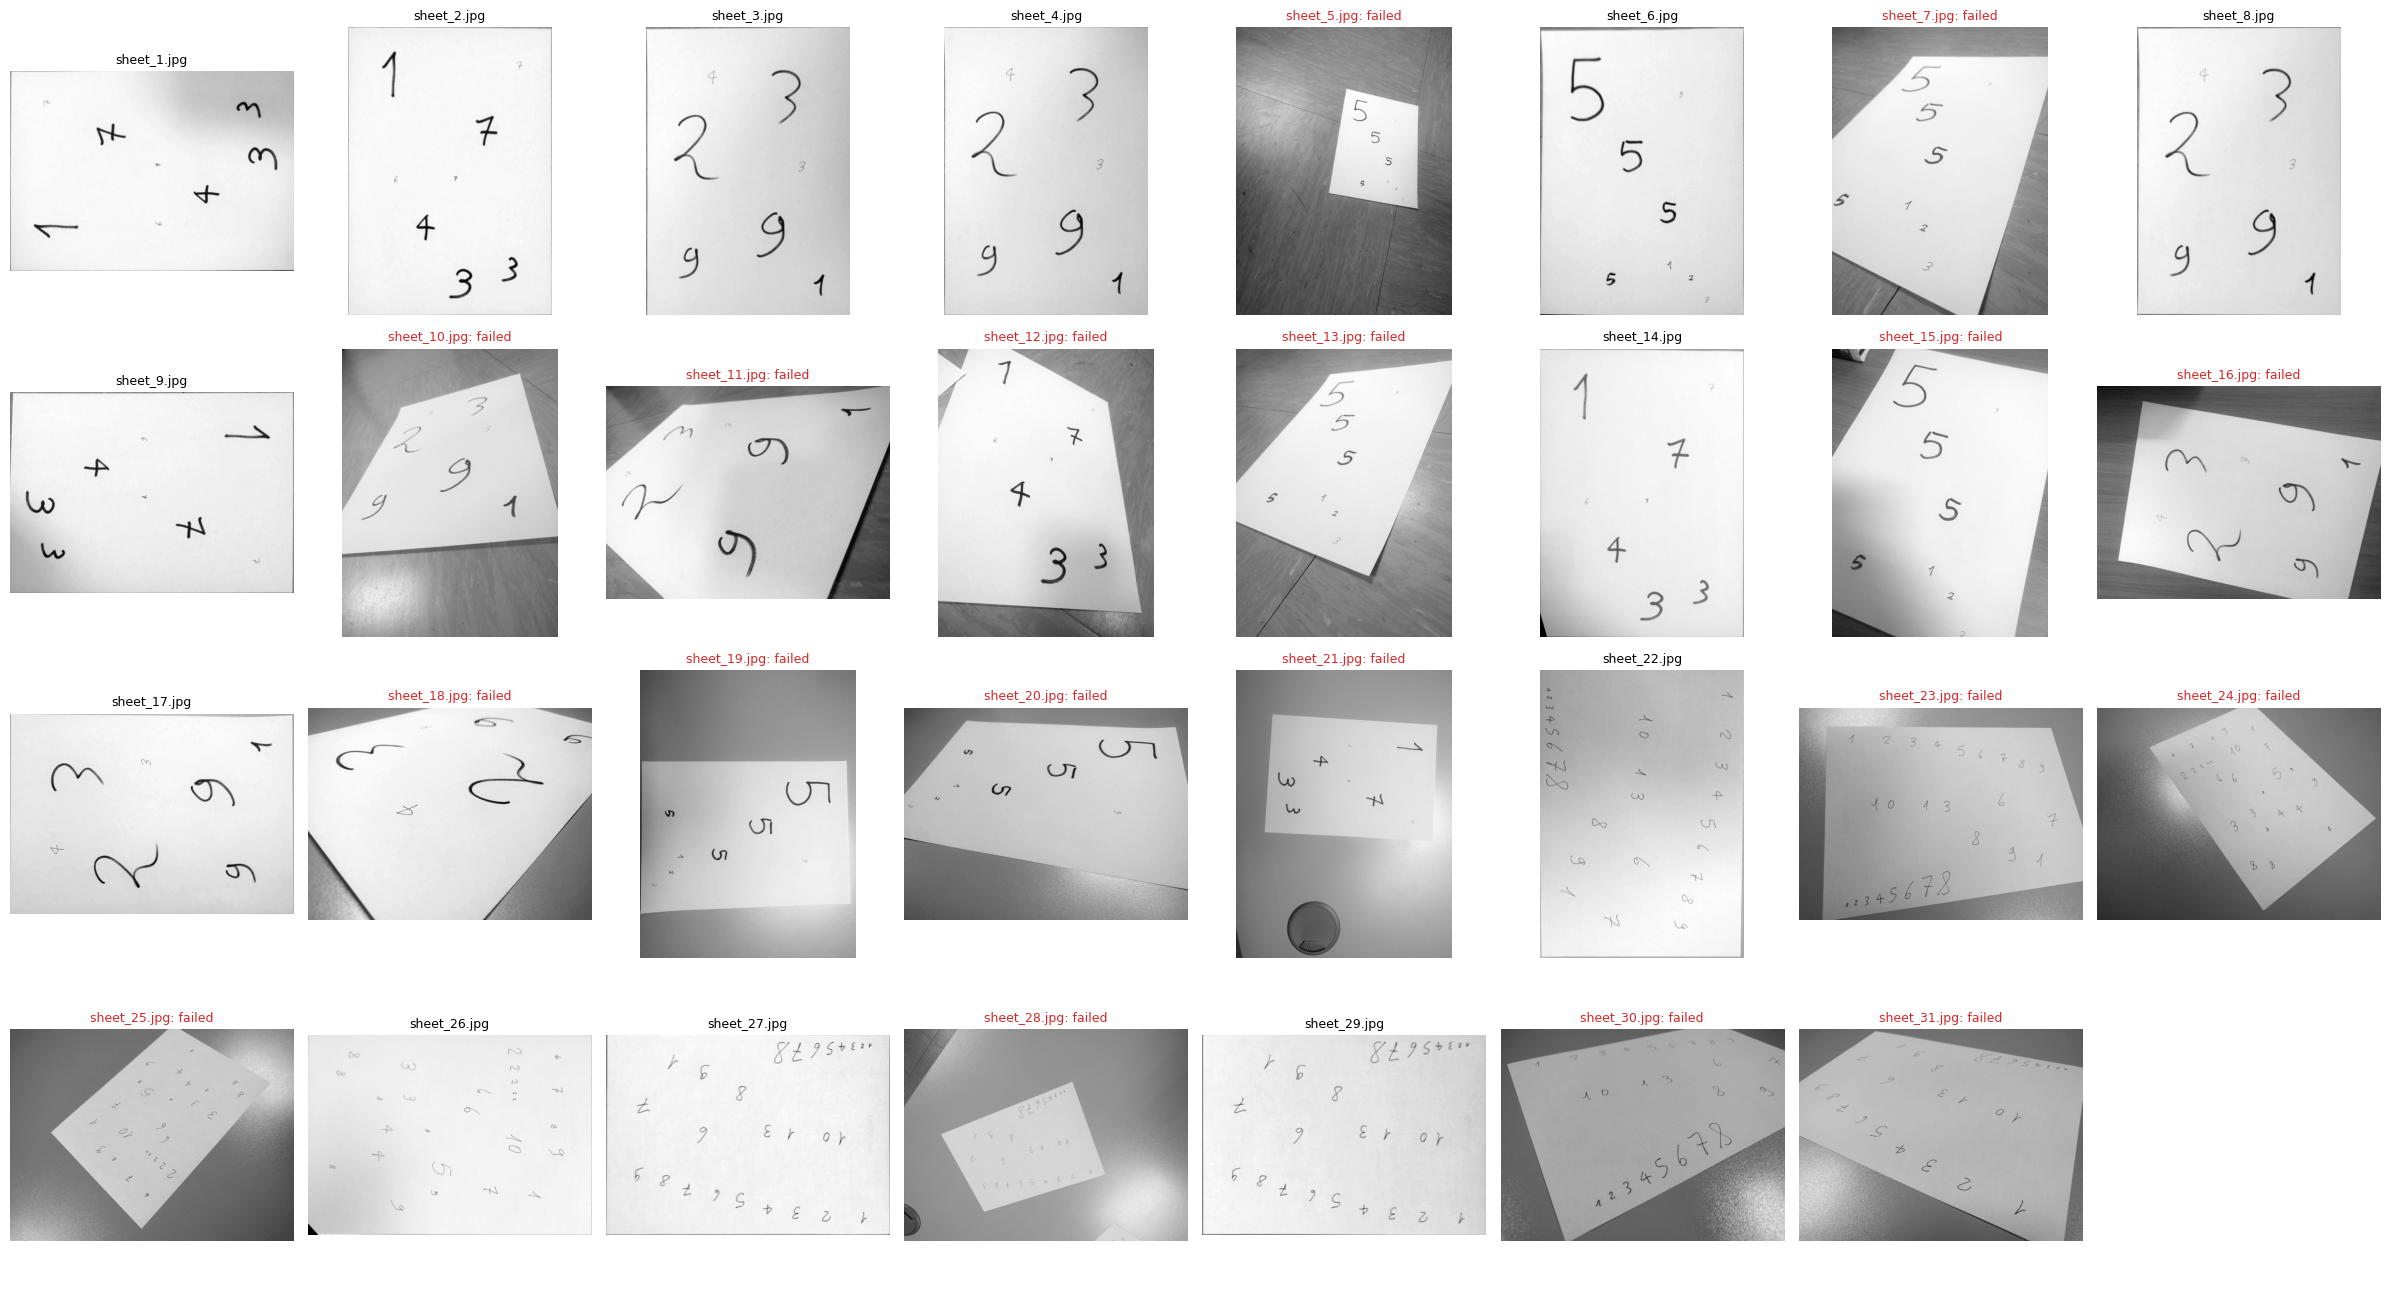

In [6]:
results = []
for path in photos:
    gray = load_gray(path)
    mask = sheet_mask(gray)
    *_, lines = border_lines(mask)
    corners, score = find_corners(mask, lines)
    results.append({"photo": path.split("/")[-1], "gray": gray, "mask": mask, "corners": corners, "overlap": score,
                    "rectified": corners is not None})
summary = pd.DataFrame(results)[["photo", "overlap", "rectified"]]
print(f"rectified automatically: {summary['rectified'].sum()} of {len(summary)}")

fig, axes = plt.subplots(4, 8, figsize=(24, 13))
for ax, r in zip(axes.flat, results):
    if r["rectified"]:
        ax.imshow(rectify(r["gray"], r["corners"])[0], cmap="gray")
        ax.set_title(r["photo"], fontsize=9)
    else:
        ax.imshow(r["gray"], cmap="gray")
        ax.set_title(f"{r['photo']}: failed", fontsize=9, color="tab:red")
for ax in axes.flat:
    ax.axis("off")
fig.tight_layout()
plt.show()

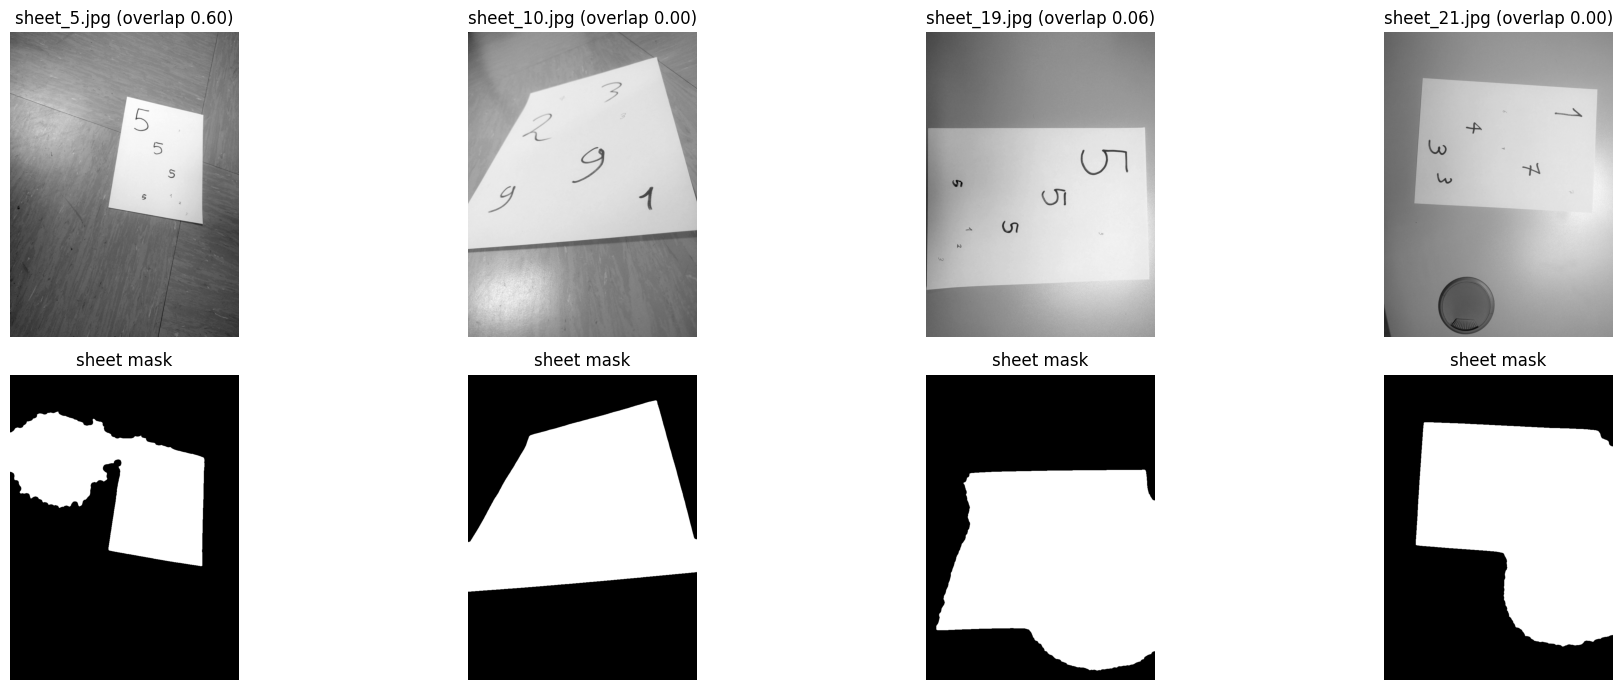

In [7]:
failures = [r for r in results if not r["rectified"]]
show = [failures[i] for i in (0, 2, 9, 11)] if len(failures) > 11 else failures[:4]
fig, axes = plt.subplots(2, len(show), figsize=(5 * len(show), 7))
for col, r in enumerate(show):
    axes[0, col].imshow(r["gray"], cmap="gray")
    axes[0, col].set_title(f"{r['photo']} (overlap {r['overlap']:.2f})")
    axes[1, col].imshow(r["mask"], cmap="gray")
    axes[1, col].set_title("sheet mask")
for ax in axes.flat:
    ax.axis("off")
fig.tight_layout()
plt.show()

The scanner rectifies **13 of the 31 photos** automatically. The failures (four examples above) have two causes, and in both the corner check catches the problem and reports a failure instead of returning a distorted page:

- **The sheet is not entirely in the picture** (`sheet_10`, `sheet_19`): one or more corners are outside the frame, so the mask is cut by the image border and no quadrilateral of lines matches it.
- **Glare on the floor** (`sheet_5`, `sheet_19`, `sheet_21`): reflections of the ceiling lights are as bright as the paper, so the sheet mask merges with them. A single brightness threshold cannot separate two equally bright regions.

Both could be addressed, for example by extrapolating the visible borders for partially framed sheets, or by using the paper's texture and the straightness of its edges instead of brightness alone. In a scanner app, the simpler fix is to ask the user to frame the whole page.

## 3. Reading the digits

### A digit classifier

The digits are recognized by a small CNN trained on **MNIST** (60,000 handwritten digits of 28 × 28 pixels). MNIST digits are centred, scaled to fit a 20 × 20 box and written in white on black. Ours come from photos, with different stroke widths and slight rotations, so the training images are randomly rotated, shifted and rescaled (data augmentation) to make the network more tolerant.

In [8]:
augment = transforms.Compose([transforms.RandomAffine(10, translate=(0.1, 0.1), scale=(0.85, 1.15)), transforms.ToTensor()])
mnist_train = datasets.MNIST("data", train=True, download=True, transform=augment)
mnist_test = datasets.MNIST("data", train=False, download=True, transform=transforms.ToTensor())

classifier = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Dropout(0.3), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10),
)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
loader = torch.utils.data.DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=4)
for epoch in range(3):
    classifier.train()
    for x, y in loader:
        optimizer.zero_grad()
        F.cross_entropy(classifier(x), y).backward()
        optimizer.step()
classifier.eval()
x_test, y_test = next(iter(torch.utils.data.DataLoader(mnist_test, batch_size=10_000)))
with torch.no_grad():
    print(f"MNIST test accuracy: {(classifier(x_test).argmax(1) == y_test).float().mean():.2%}")

MNIST test accuracy: 98.87%


### Segmenting the digits

On the rectified sheet, ink is darker than its surroundings. A **local threshold** handles the shading across the sheet, a morphological closing joins broken strokes, and each connected component larger than a few pixels is a candidate digit. Each one is then converted to MNIST format: thickened in proportion to its size (a large digit drawn with a thin pen looks very different from MNIST's thick strokes once scaled down), scaled into a 20 × 20 box, placed on a 28 × 28 canvas and centred on its centre of mass.

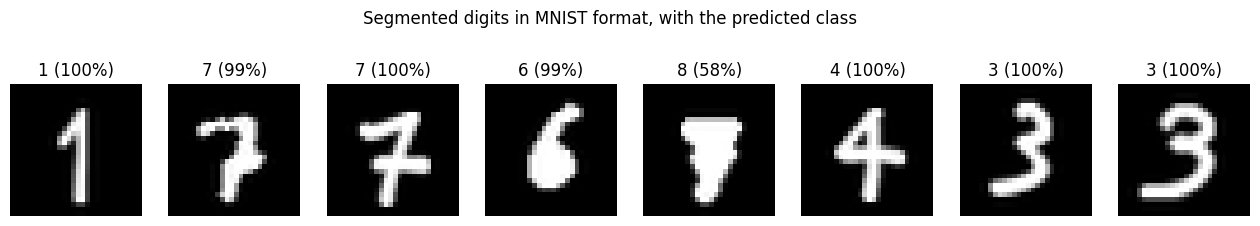

In [9]:
def segment_digits(sheet, margin=20, min_area=40):
    ink = sheet < filters.threshold_local(sheet, 51, offset=0.04)
    ink[:margin], ink[-margin:], ink[:, :margin], ink[:, -margin:] = 0, 0, 0, 0
    ink = morphology.binary_closing(ink, morphology.disk(3))
    return [r for r in measure.regionprops(measure.label(ink)) if r.area >= min_area]

def to_mnist(region):
    patch = region.image
    size = max(patch.shape)
    patch = ndi.binary_dilation(np.pad(patch, 2), iterations=max(1, size // 25)).astype(float)
    scale = 20 / max(patch.shape)
    patch = transform.resize(patch, (max(1, round(patch.shape[0] * scale)), max(1, round(patch.shape[1] * scale))), anti_aliasing=True)
    canvas = np.zeros((28, 28))
    top, left = (28 - patch.shape[0]) // 2, (28 - patch.shape[1]) // 2
    canvas[top:top + patch.shape[0], left:left + patch.shape[1]] = patch
    cy, cx = ndi.center_of_mass(canvas)
    return np.clip(ndi.shift(canvas, (14 - cy, 14 - cx)), 0, 1)

def read(sheet):
    regions = segment_digits(sheet)
    if not regions:
        return [], np.zeros((0, 10))
    batch = torch.tensor(np.stack([to_mnist(r) for r in regions]), dtype=torch.float32)[:, None]
    with torch.no_grad():
        probs = F.softmax(classifier(batch), 1).numpy()
    return regions, probs

sheet = rectify(results[1]["gray"], results[1]["corners"])[0]
regions, probs = read(sheet)
fig, axes = plt.subplots(1, len(regions), figsize=(2 * len(regions), 2.4))
for ax, r, p in zip(np.atleast_1d(axes), regions, probs):
    ax.imshow(to_mnist(r), cmap="gray")
    ax.set_title(f"{p.argmax()} ({p.max():.0%})")
    ax.axis("off")
fig.suptitle("Segmented digits in MNIST format, with the predicted class", y=1.08)
plt.show()

### Which way is up?

The homography fixes the shape of the sheet but not its orientation: the same rectangle can be presented rotated by 90°, 180° or 270°, and the digits then lie on their side or upside down. The classifier itself can solve this: we read the sheet in all four orientations and keep the one where the predictions are most **confident**. Upright digits look like MNIST digits, while rotated ones produce hesitant predictions.

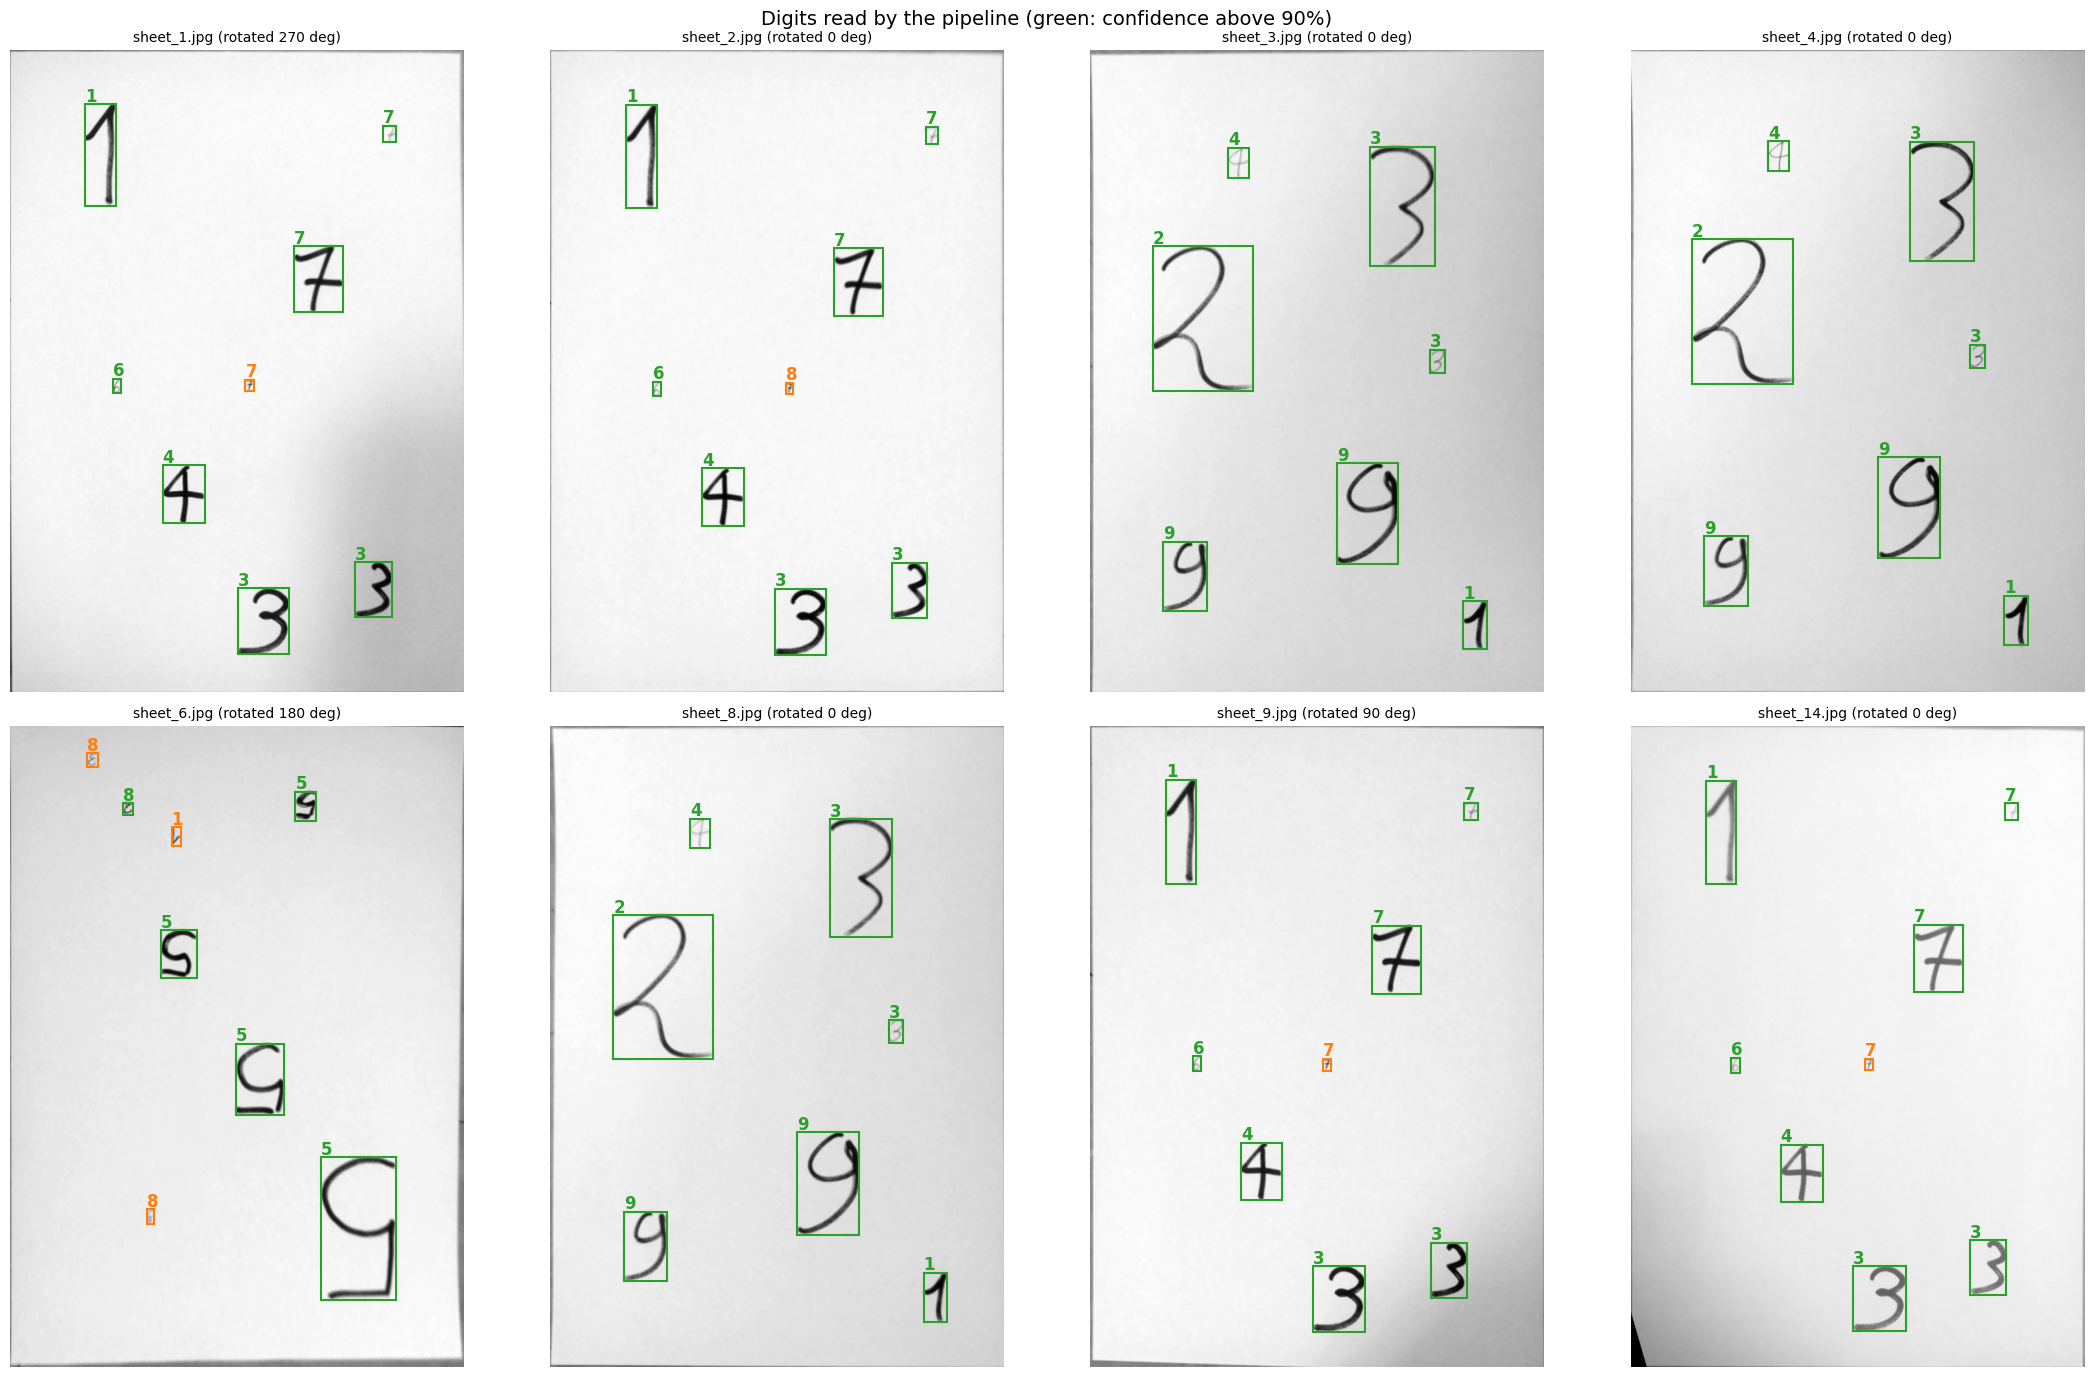

,photo,rotation,digits found,mean confidence
0,sheet_1.jpg,270,8,1.00
1,sheet_2.jpg,0,8,1.00
2,sheet_3.jpg,0,7,0.97
3,sheet_4.jpg,0,7,0.98
4,sheet_6.jpg,180,8,0.96
5,sheet_8.jpg,0,7,0.98
6,sheet_9.jpg,90,8,1.00
7,sheet_14.jpg,0,8,1.00


In [10]:
def read_upright(sheet):
    best = None
    for k in range(4):
        rotated = np.rot90(sheet, k)
        regions, probs = read(rotated)
        big = [i for i, r in enumerate(regions) if max(r.image.shape) > 25]
        confidence = probs[big].max(1).mean() if big else 0.0
        if best is None or confidence > best[0]:
            best = (confidence, k, rotated, regions, probs)
    return best

def show_reading(ax, rotated, regions, probs, title):
    ax.imshow(rotated, cmap="gray")
    for r, p in zip(regions, probs):
        y0, x0, y1, x1 = r.bbox
        color = "tab:green" if p.max() > 0.9 else "tab:orange"
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, color=color, lw=1.5))
        ax.text(x0, y0 - 4, f"{p.argmax()}", color=color, fontsize=12, weight="bold")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

ok = [r for r in results if r["rectified"]]
fig, axes = plt.subplots(2, 4, figsize=(22, 14))
readings = []
for ax, r in zip(axes.flat, ok[:8]):
    confidence, k, rotated, regions, probs = read_upright(rectify(r["gray"], r["corners"])[0])
    readings.append({"photo": r["photo"], "rotation": 90 * k, "digits found": len(regions), "mean confidence": confidence})
    show_reading(ax, rotated, regions, probs, f"{r['photo']} (rotated {90 * k} deg)")
fig.suptitle("Digits read by the pipeline (green: confidence above 90%)", fontsize=14)
fig.tight_layout()
plt.show()
pd.DataFrame(readings).round(2)

On these sheets the pipeline reads every **large digit** correctly, often with confidence close to 100%. The orientation search turns the landscape photos (`sheet_1`, `sheet_9`) the right way up. The small digits written in pencil, only a few pixels high after downscaling, are harder: most are still read correctly, but several get low-confidence or wrong labels (orange boxes), for example a tiny 7 read as an 8.

The one clear failure is **`sheet_6`**, which is shown upside down. Its digits are all 5s, and a 5 rotated by 180 degrees still looks like a slanted 5 (or a 9) to the classifier, so confidence alone cannot tell up from down. This is a limit of using a digit classifier to decide the orientation: it works when the page contains digits that change identity or become unrecognizable when rotated (1, 3, 4, 7), and fails on symmetric ones. A real scanner would combine several cues, such as the position of the text block or the device orientation sensor.

## Summary

- A classic pipeline of **thresholding, morphology, Canny edges and the Hough transform** finds the borders of a sheet; intersecting pairs of opposite borders gives its corners.
- A **homography** estimated from the four corners rectifies the sheet to a fronto-parallel A4 page.
- The pipeline works when the whole sheet is visible against a darker background. It fails when **part of the sheet is outside the photo** or when **glare** makes the floor as bright as the paper; both failures are detected automatically by checking the quadrilateral against the mask, instead of producing a wrong result.
- Connected components plus a small **CNN trained on MNIST** read the digits. Converting the crops to MNIST's format (stroke width, scale, centring) matters as much as the classifier, and the classifier's confidence also resolves the **orientation** of the page.